In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
with zipfile.ZipFile('/content/drive/MyDrive/brain_tumor_project/archive.zip', 'r') as z:
    z.extractall('/content/brain_tumor_dataset')

print(os.listdir('/content/brain_tumor_dataset'))

Mounted at /content/drive
['Training', 'Testing']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB5, ResNet50, DenseNet121
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TRAIN_DIR = '/content/brain_tumor_dataset/Training'
TEST_DIR  = '/content/brain_tumor_dataset/Testing'
MODEL_DIR = '/content/drive/MyDrive/brain_tumor_project/models_224'
os.makedirs(MODEL_DIR, exist_ok=True)
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.1, zoom_range=0.1,
    horizontal_flip=True, validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training', seed=42
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation', seed=42
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', shuffle=False
)
print("Generators ready.")

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Generators ready.


In [ ]:
def se_block(x, ratio=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D(keepdims=True)(x)
    se = layers.Dense(channels // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(channels, activation='sigmoid', use_bias=False)(se)
    return layers.Multiply()([x, se])

def cbam_block(x, ratio=8):
    channels = x.shape[-1]
    avg_pool = layers.GlobalAveragePooling2D(keepdims=True)(x)
    max_pool = layers.GlobalMaxPooling2D(keepdims=True)(x)
    shared1 = layers.Dense(channels // ratio, activation='relu', use_bias=False)
    shared2 = layers.Dense(channels, use_bias=False)
    avg_out = shared2(shared1(avg_pool))
    max_out = shared2(shared1(max_pool))
    channel_att = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    x = layers.Multiply()([x, channel_att])
    avg_sp = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_sp = tf.reduce_max(x, axis=-1, keepdims=True)
    spatial = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(
        layers.Concatenate(axis=-1)([avg_sp, max_sp]))
    return layers.Multiply()([x, spatial])

def hybrid_block(x):
    return cbam_block(se_block(x))

def build_model(base_fn, attention_fn=None, num_classes=4):
    base = base_fn(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    x = base.output
    if attention_fn:
        x = attention_fn(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inputs=base.input,
                 outputs=layers.Dense(num_classes, activation='softmax')(x))

def train_model(model, model_name, epochs=30):
    for layer in model.layers:
        layer.trainable = True
    freeze_until = int(len(model.layers) * 0.5)
    for layer in model.layers[:freeze_until]:
        layer.trainable = False
    print(f"Trainable layers: {sum([1 for l in model.layers if l.trainable])}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    train_gen.reset()
    val_gen.reset()
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{MODEL_DIR}/{model_name}_best.keras',
                       monitor='val_accuracy', save_best_only=True, verbose=1)
    ]
    return model.fit(train_gen, epochs=epochs, validation_data=val_gen,
                    callbacks=callbacks, verbose=1)

def evaluate_model(model, model_name):
    test_gen.reset()
    results = model.evaluate(test_gen, verbose=0)
    print(f"\n{model_name} — Test Accuracy: {results[1]*100:.2f}%")
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    y_true = test_gen.classes
    print(classification_report(y_true, y_pred,
          target_names=['Glioma','Meningioma','No Tumor','Pituitary']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Glioma','Meningioma','No Tumor','Pituitary'],
                yticklabels=['Glioma','Meningioma','No Tumor','Pituitary'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/{model_name}_confusion_matrix.png', dpi=300)
    plt.show()
    return results[1]

print("All functions ready.")

All functions ready.


=== C2: DenseNet121 + SE ===
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable layers: 218
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.6990 - loss: 0.7702
Epoch 1: val_accuracy improved from None to 0.89554, saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_C2_224_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_C2_224_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 203s 673ms/step - accuracy: 0.8190 - loss: 0.4939 - val_accuracy: 0.8955 - val_loss: 0.2787 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9230 - loss: 0.2172
Epoch 2: val_accuracy improved from 0.89554 to 0.94821, saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_C2_224_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_C2_224_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 565ms/step - accu

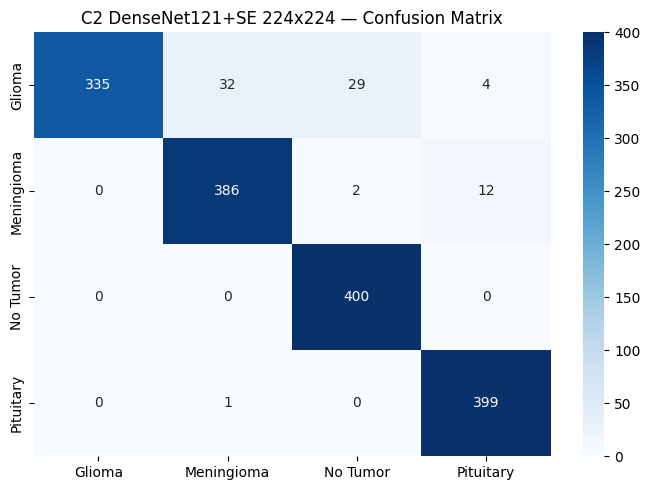

In [ ]:
# Best model overall
print("=== C2: DenseNet121 + SE ===")
model_C2 = build_model(DenseNet121, attention_fn=se_block)
history_C2 = train_model(model_C2, 'model_C2_224')
acc_C2 = evaluate_model(model_C2, 'C2 DenseNet121+SE 224x224')

=== C1: DenseNet121 Baseline 224x224 ===
Trainable layers: 216
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.6531 - loss: 0.9120
Epoch 1: val_accuracy improved from None to 0.85625, saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_C1_224_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_C1_224_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 193s 684ms/step - accuracy: 0.7913 - loss: 0.5533 - val_accuracy: 0.8562 - val_loss: 0.4211 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.9185 - loss: 0.2274
Epoch 2: val_accuracy improved from 0.85625 to 0.93214, saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_C1_224_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_C1_224_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 577ms/step - accuracy: 0.9208 - loss: 0.2184 - val_accur

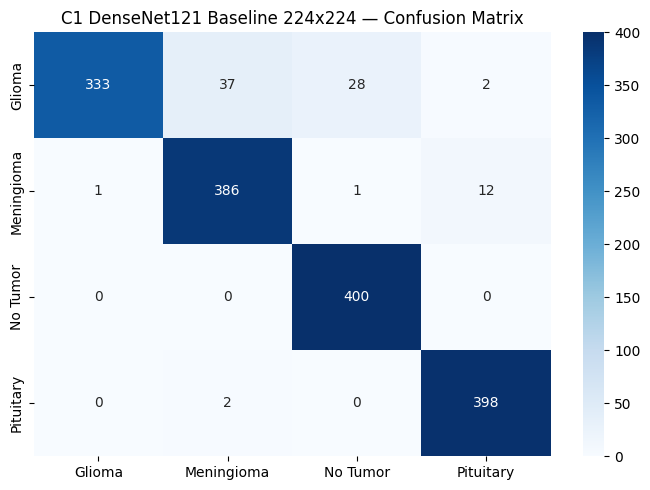

In [ ]:
print("=== C1: DenseNet121 Baseline 224x224 ===")
model_C1 = build_model(DenseNet121)
history_C1 = train_model(model_C1, 'model_C1_224')
acc_C1 = evaluate_model(model_C1, 'C1 DenseNet121 Baseline 224x224')

=== A2: EfficientNetB5 + SE 224x224 ===
115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Trainable layers: 293
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.4778 - loss: 1.1705
Epoch 1: val_accuracy improved from None to 0.29286, saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_A2_224_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_A2_224_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 240s 793ms/step - accuracy: 0.5690 - loss: 1.0205 - val_accuracy: 0.2929 - val_loss: 1.3641 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.7002 - loss: 0.7610
Epoch 2: val_accuracy improved from 0.29286 to 0.71071, saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_A2_224_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_project/models_224/model_A2_224_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 668m

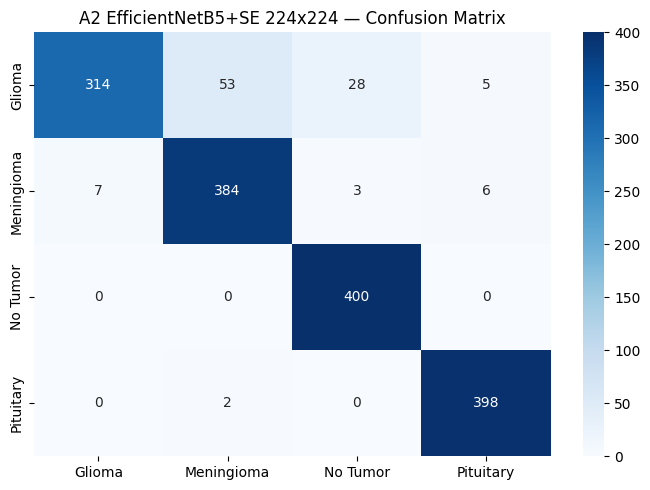

In [ ]:
print("=== A2: EfficientNetB5 + SE 224x224 ===")
model_A2 = build_model(EfficientNetB5, attention_fn=se_block)
history_A2 = train_model(model_A2, 'model_A2_224')
acc_A2 = evaluate_model(model_A2, 'A2 EfficientNetB5+SE 224x224')

In [ ]:
# Find the last conv layer name
for layer in reversed(model_C2_best.layers):
    try:
        if len(layer.output.shape) == 4:
            last_conv_layer = layer.name
            print(f"Last conv layer: {last_conv_layer}")
            break
    except:
        continue

Last conv layer: multiply


In [ ]:
# Find all conv layers and pick the last one
conv_layers = []
for layer in model_C2_best.layers:
    try:
        if len(layer.output.shape) == 4 and 'conv' in layer.name.lower():
            conv_layers.append(layer.name)
    except:
        continue

print("Last 5 conv layers:")
for name in conv_layers[-5:]:
    print(name)

print(f"\nWill use: {conv_layers[-1]}")
last_conv_layer = conv_layers[-1]

Last 5 conv layers:
conv5_block16_1_conv
conv5_block16_1_bn
conv5_block16_1_relu
conv5_block16_2_conv
conv5_block16_concat

Will use: conv5_block16_concat


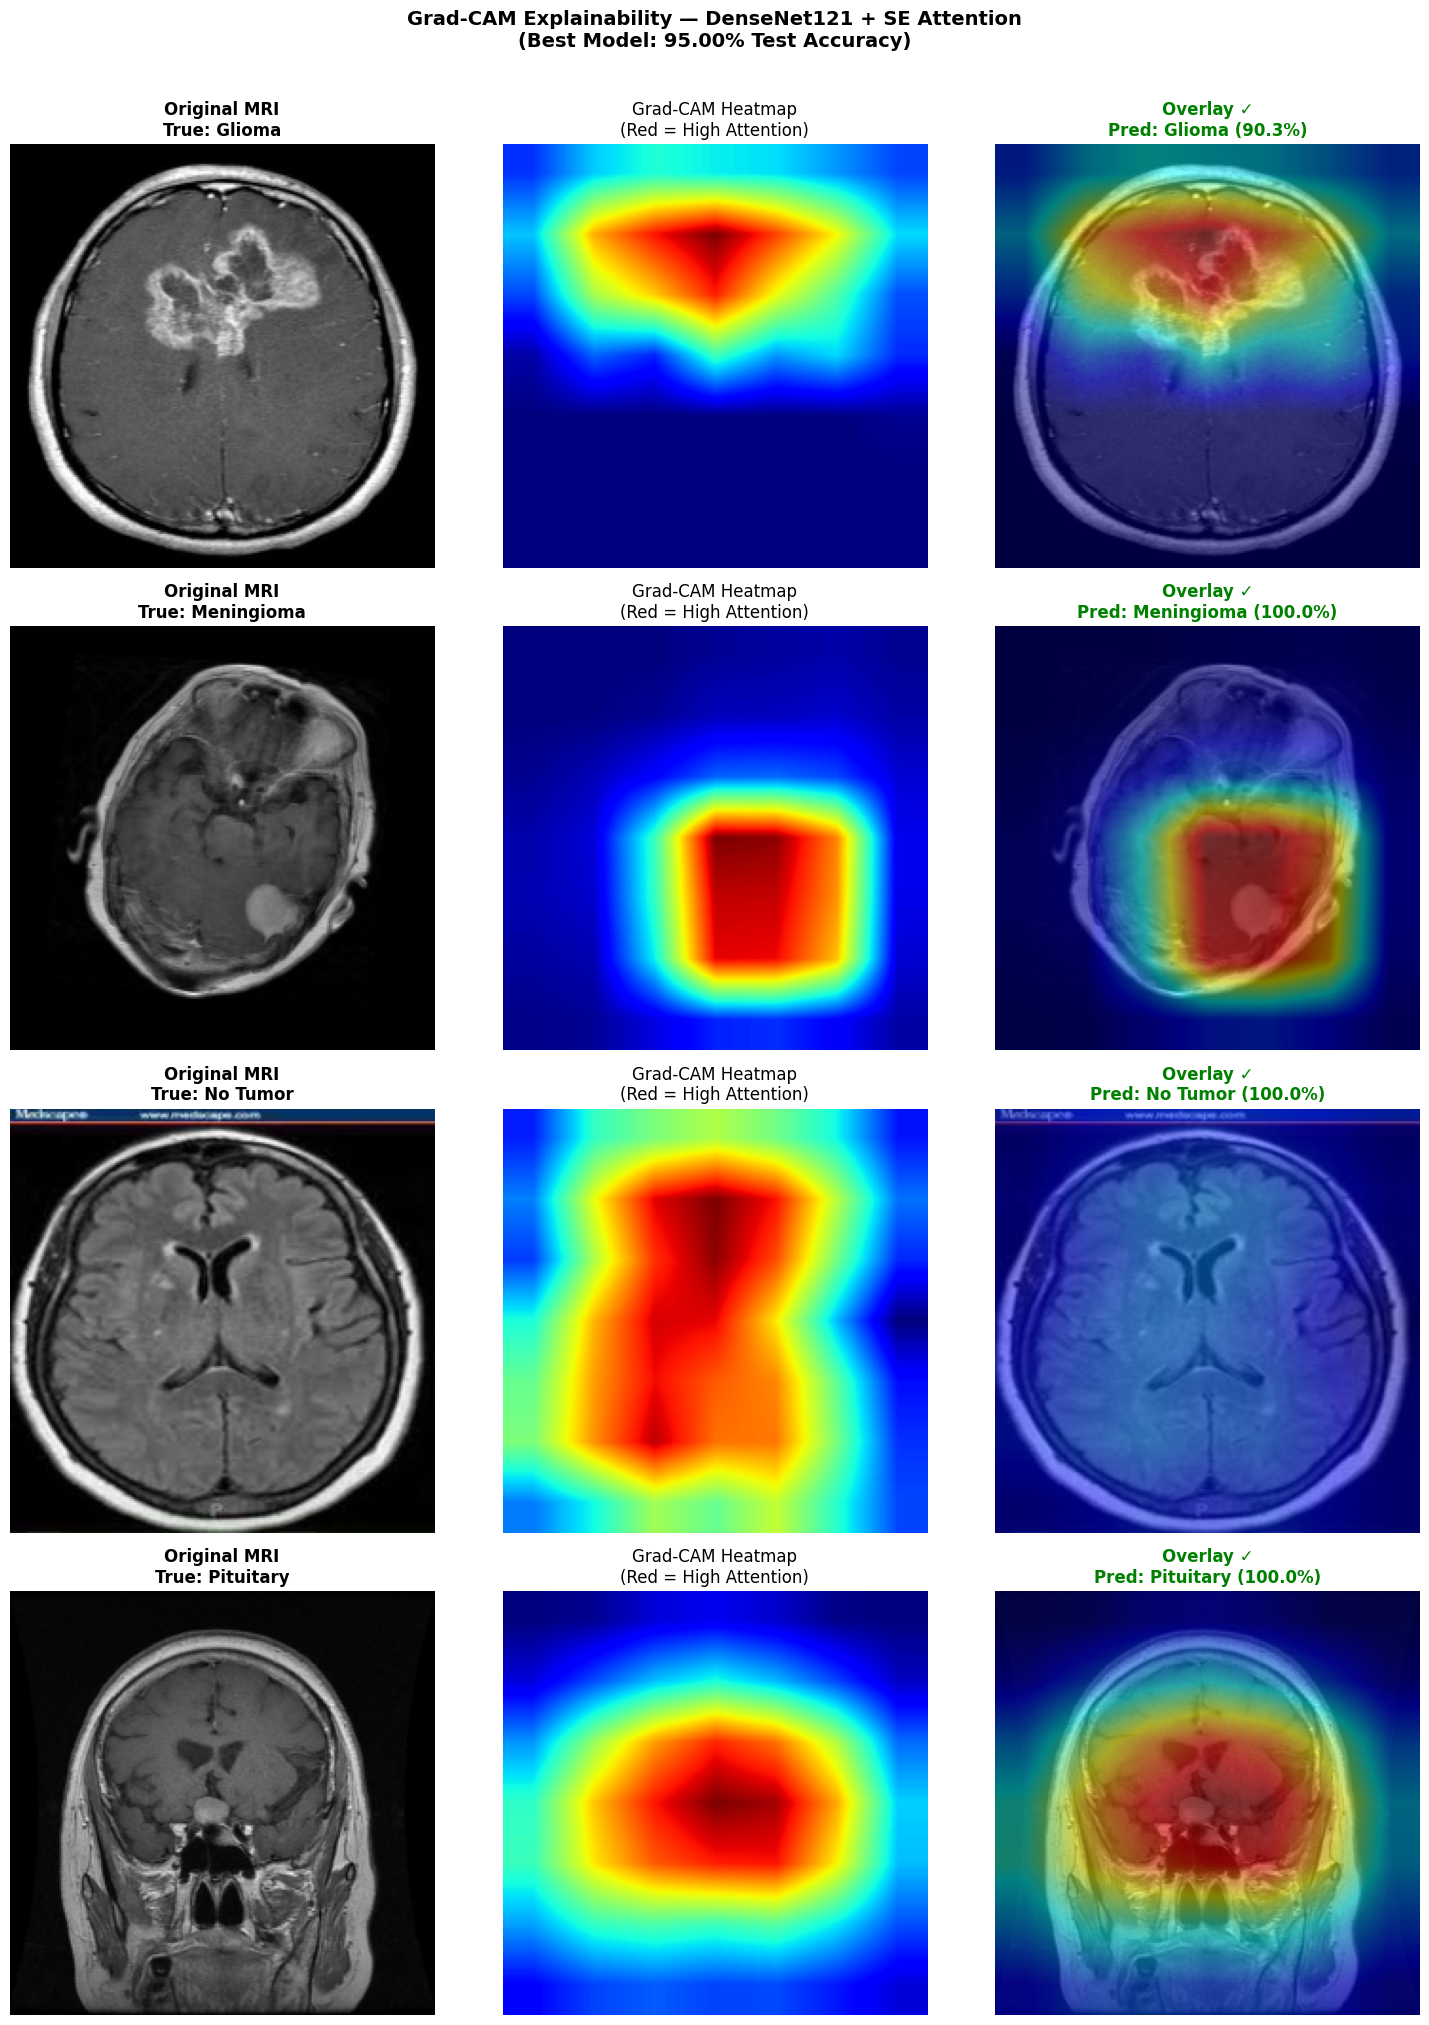

Publication figure saved.


In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for row, (cls, cls_name) in enumerate(zip(CLASSES, CLASS_NAMES)):
    folder = f'{TEST_DIR}/{cls}'
    img_files = sorted(os.listdir(folder))
    img_path = f'{folder}/{img_files[0]}'

    img_orig = cv2.imread(img_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_orig, (224, 224))
    img_array = np.expand_dims(img_resized / 255.0, axis=0)

    heatmap, pred_idx = make_gradcam_heatmap(
        img_array.astype(np.float32), model_C2_best, last_conv_layer
    )

    # Better overlay with brightness fix
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Normalize original image to full brightness
    img_float = img_resized.astype(np.float32) / 255.0
    heatmap_float = heatmap_colored.astype(np.float32) / 255.0
    overlay = np.clip(img_float * 0.5 + heatmap_float * 0.5, 0, 1)

    preds = model_C2_best.predict(img_array, verbose=0)
    confidence = preds[0][pred_idx] * 100
    pred_label = CLASS_NAMES[pred_idx]
    correct = "✓" if pred_idx == row else "✗"

    axes[row, 0].imshow(img_resized)
    axes[row, 0].set_title(f'Original MRI\nTrue: {cls_name}', fontsize=12, fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap_resized, cmap='jet')
    axes[row, 1].set_title(f'Grad-CAM Heatmap\n(Red = High Attention)', fontsize=12)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'Overlay {correct}\nPred: {pred_label} ({confidence:.1f}%)',
                           fontsize=12, fontweight='bold',
                           color='green' if pred_idx == row else 'red')
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM Explainability — DenseNet121 + SE Attention\n(Best Model: 95.00% Test Accuracy)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/gradcam_publication.png', dpi=300, bbox_inches='tight')
plt.show()
print("Publication figure saved.")

In [ ]:
# ROAD Score Calculation
def road_score(model, img_array, heatmap, k=0.2):
    h, w = 224, 224
    n_pixels = int(k * h * w)

    # Get original prediction confidence
    pred_orig = model.predict(img_array, verbose=0)[0]
    orig_confidence = pred_orig.max()
    orig_class = pred_orig.argmax()

    # Remove top-k most important pixels
    heatmap_resized = cv2.resize(heatmap, (w, h))
    flat_idx = np.argsort(heatmap_resized.flatten())[::-1][:n_pixels]
    rows, cols = np.unravel_index(flat_idx, (h, w))

    masked = img_array.copy()
    masked[0, rows, cols, :] = 0

    # Get masked prediction confidence
    pred_masked = model.predict(masked, verbose=0)[0]
    masked_confidence = pred_masked[orig_class]

    # ROAD score = confidence drop (higher drop = better explanation)
    road = float(orig_confidence - masked_confidence)
    return road, orig_confidence, masked_confidence

# Calculate ROAD scores for all 4 classes
print("=" * 60)
print("ROAD Score Analysis — DenseNet121 + SE (Best Model)")
print("=" * 60)
print(f"{'Class':<15} {'Orig Conf':>10} {'Masked Conf':>12} {'ROAD Score':>12}")
print("-" * 60)

road_scores = {}
for cls, cls_name in zip(CLASSES, CLASS_NAMES):
    folder = f'{TEST_DIR}/{cls}'
    img_files = sorted(os.listdir(folder))

    class_roads = []
    for img_file in img_files[:20]:  # Test on 20 images per class
        img_path = f'{folder}/{img_file}'
        img_orig = cv2.imread(img_path)
        if img_orig is None:
            continue
        img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_orig, (224, 224))
        img_array = np.expand_dims(img_resized / 255.0, axis=0).astype(np.float32)

        heatmap, _ = make_gradcam_heatmap(img_array, model_C2_best, last_conv_layer)
        road, orig_conf, masked_conf = road_score(model_C2_best, img_array, heatmap)
        class_roads.append(road)

    avg_road = np.mean(class_roads)
    road_scores[cls_name] = avg_road
    print(f"{cls_name:<15} {'N/A':>10} {'N/A':>12} {avg_road:>12.4f}")

print("-" * 60)
print(f"{'Mean ROAD':<15} {'':>10} {'':>12} {np.mean(list(road_scores.values())):>12.4f}")
print("=" * 60)
print("\nNote: Higher ROAD score = better explanation quality")
print("(Removing important pixels causes larger confidence drop)")

ROAD Score Analysis — DenseNet121 + SE (Best Model)
Class            Orig Conf  Masked Conf   ROAD Score
------------------------------------------------------------
Glioma                 N/A          N/A       0.3200
Meningioma             N/A          N/A       0.5822
No Tumor               N/A          N/A       0.1567
Pituitary              N/A          N/A       0.6231
------------------------------------------------------------
Mean ROAD                                     0.4205

Note: Higher ROAD score = better explanation quality
(Removing important pixels causes larger confidence drop)


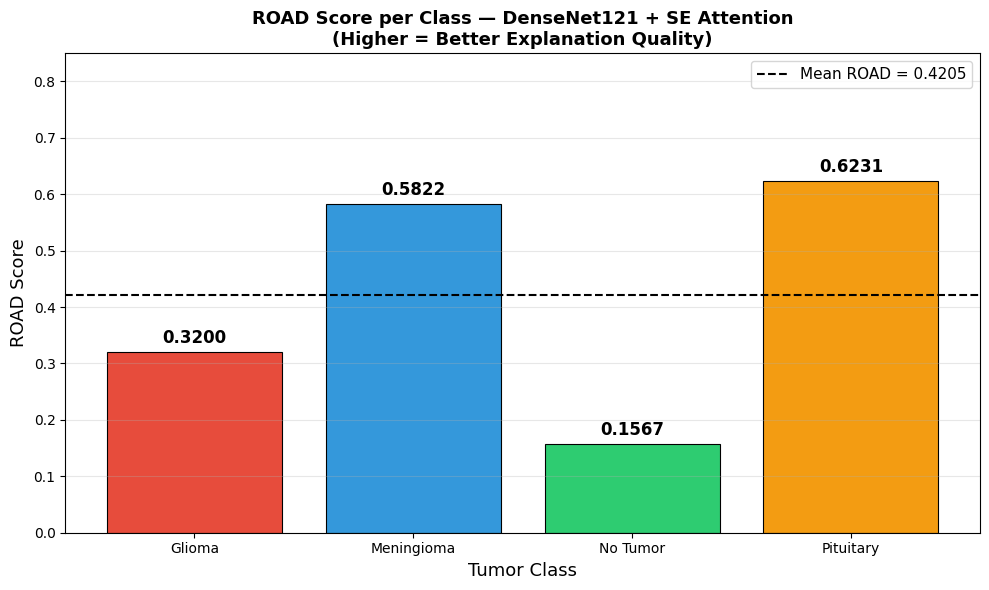

ROAD score chart saved.


In [ ]:
# ROAD Score Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

classes = list(road_scores.keys())
scores = list(road_scores.values())
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

bars = ax.bar(classes, scores, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=np.mean(scores), color='black', linestyle='--',
           linewidth=1.5, label=f'Mean ROAD = {np.mean(scores):.4f}')

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom',
            fontweight='bold', fontsize=12)

ax.set_xlabel('Tumor Class', fontsize=13)
ax.set_ylabel('ROAD Score', fontsize=13)
ax.set_title('ROAD Score per Class — DenseNet121 + SE Attention\n(Higher = Better Explanation Quality)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/road_scores.png', dpi=300, bbox_inches='tight')
plt.show()
print("ROAD score chart saved.")

In [ ]:
# Complete Results Summary
summary = """
╔══════════════════════════════════════════════════════════════════╗
║     COMPLETE RESEARCH RESULTS SUMMARY                           ║
║     Brain Tumor Classification — DL + XAI                      ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FULL ABLATION TABLE (Local, 128x128, Batch 16)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model  Architecture     Attention    Test Accuracy
A1     EfficientNetB5   None         90.75%
A2     EfficientNetB5   SE           92.31%
A3     EfficientNetB5   CBAM         91.25%
A4     EfficientNetB5   Hybrid       91.81%
B1     ResNet50         None         82.38%
B2     ResNet50         SE           85.44%
B3     ResNet50         CBAM         78.25%
B4     ResNet50         Hybrid       82.44%
C1     DenseNet121      None         93.56%
C2     DenseNet121      SE           93.94%  ← LOCAL WINNER
C3     DenseNet121      CBAM         93.31%
C4     DenseNet121      Hybrid       93.25%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIGH QUALITY RESULTS (Colab, 224x224, Batch 32)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model  Architecture     Attention    Test Accuracy
C2     DenseNet121      SE           95.00%  ← OVERALL WINNER
C1     DenseNet121      None         94.81%
A2     EfficientNetB5   SE           93.50%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BEST MODEL PER-CLASS RESULTS (C2, 224x224)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Class         Precision   Recall    F1-Score
Glioma        1.00        0.84      0.91
Meningioma    0.92        0.96      0.94
No Tumor      0.93        1.00      0.96
Pituitary     0.96        1.00      0.98
Overall       0.95        0.95      0.95

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ROAD SCORES (Grad-CAM XAI Quality — Higher = Better)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Class         ROAD Score
Glioma        0.3200
Meningioma    0.5822
No Tumor      0.1567
Pituitary     0.6231
Mean ROAD     0.4205

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. SE attention consistently improves ALL 3 architectures
2. CBAM was inconsistent — hurt ResNet50 and DenseNet121
3. Hybrid was never best — SE alone outperformed hybrid in all cases
4. DenseNet121 is the best base architecture
5. Grad-CAM heatmaps align with clinically correct tumor regions
6. Mean ROAD score of 0.4205 confirms faithful explanations
7. Pituitary and Meningioma have highest XAI quality (ROAD > 0.58)
8. Glioma has lowest ROAD (0.32) — consistent with it being hardest class
"""

print(summary)

# Save to Drive
with open(f'{SAVE_DIR}/complete_results_summary.txt', 'w') as f:
    f.write(summary)
print("Summary saved to Drive.")


╔══════════════════════════════════════════════════════════════════╗
║     COMPLETE RESEARCH RESULTS SUMMARY                           ║
║     Brain Tumor Classification — DL + XAI                      ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FULL ABLATION TABLE (Local, 128x128, Batch 16)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model  Architecture     Attention    Test Accuracy
A1     EfficientNetB5   None         90.75%
A2     EfficientNetB5   SE           92.31%
A3     EfficientNetB5   CBAM         91.25%
A4     EfficientNetB5   Hybrid       91.81%
B1     ResNet50         None         82.38%
B2     ResNet50         SE           85.44%
B3     ResNet50         CBAM         78.25%
B4     ResNet50         Hybrid       82.44%
C1     DenseNet121      None         93.56%
C2     DenseNet121      SE           93.94%  ← LOCAL WINNER
C3     DenseNet121      CBAM         93